<a href="https://colab.research.google.com/github/Isabela-Tellez/BootcampIA/blob/main/04.%20Abril-29/ModeladoER_BBDD_TechNova_SQLite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: linear-gradient(135deg, #4B2A82 0%, #1A1F4E 100%); padding: 40px; border-radius: 12px; color: white; text-align: center;">

<h1 style="color: white; margin: 0; font-size: 2.5em;">🏢 TechNova</h1>
<h2 style="color: #2EC4B6; margin: 10px 0 20px 0; font-weight: 300;">Modelado Relacional con SQLite</h2>
<p style="font-size: 1.1em; margin: 0;">Departamentos · Empleados · Proyectos</p>

</div>

<div style="background: #F5F0FA; border-left: 6px solid #4B2A82; padding: 20px; border-radius: 6px; margin: 20px 0;">

### 🎯 Objetivos de aprendizaje

Al final de esta sesión seréis capaces de:

- ✅ **Traducir un modelo E/R** a `CREATE TABLE` en SQLite.
- ✅ Implementar **relaciones 1:N y N:M** con claves foráneas.
- ✅ Usar **tablas intermedias** para resolver relaciones N:M.
- ✅ Comprender la diferencia entre `ON DELETE CASCADE` y `ON DELETE RESTRICT`.
</div>

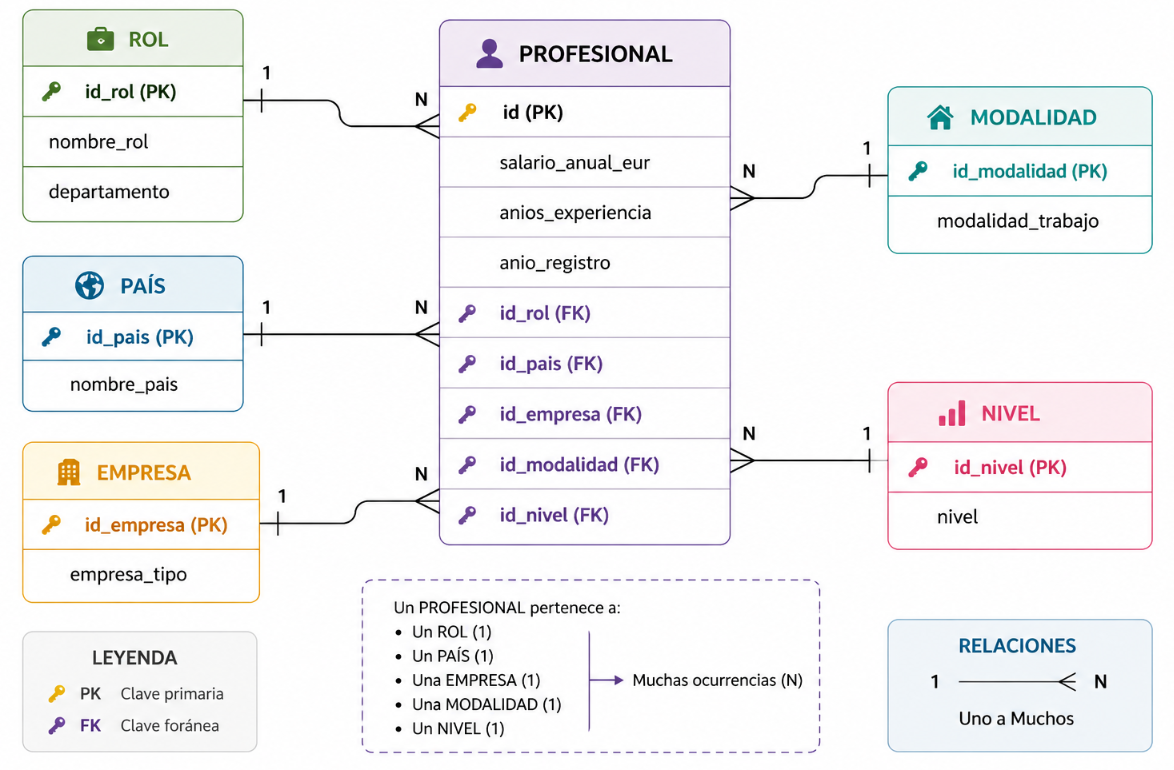

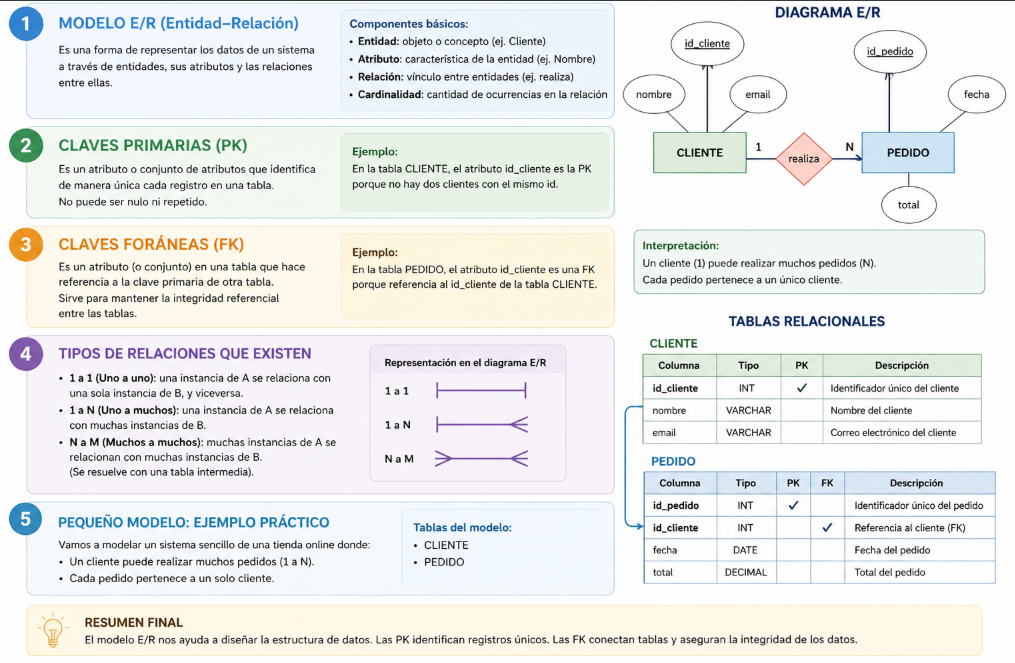

## Conceptos clave

| Concepto | Qué es |
|----------|--------|
| **Clave primaria** (PK) | Identificador único de cada fila. Nunca se repite. |
| **Clave foránea** (FK) | Columna que referencia la PK de otra tabla. El enlace. |
| **Relación 1:1** | Un cliente de hotel ocupa una única habitación. |
| **Relación 1:N** | Un departamento tiene muchos empleados. |
| **Relación N:M** | Un empleado puede tener muchos proyectos y un proyecto muchos empleados. |



## 🎯 Objetivo de la sesión

Vamos a construir el modelo de datos de **TechNova**, una empresa con:
- 🏢 **Departamentos** (Datos, Frontend, Producto…)
- 👥 **Empleados** (cada uno pertenece a UN departamento)
- 📋 **Proyectos** (cada empleado puede estar en VARIOS proyectos)

<div style="background: #E8F8F6; border-left: 6px solid #2EC4B6; padding: 20px; border-radius: 6px; margin: 20px 0;">

### 📐 Modelo E/R que vamos a construir

```
┌─────────────────┐         ┌─────────────────┐         ┌─────────────────┐
│  DEPARTAMENTO   │         │    EMPLEADOS    │         │    PROYECTO     │
├─────────────────┤   1:N   ├─────────────────┤         ├─────────────────┤
│ 🔑 id           │─────────│ 🔑 id          │         │ 🔑 id          │
│   nombre        │         │   nombre        │         │   nombre        │
│   ubicacion     │         │   email         │         │   presupuesto   │
└─────────────────┘         │   salario       │         └─────────────────┘
                            │🔗departamento_id│                  │
                            └─────────────────┘                  │
                                     │                           │
                                     │  Empleado N:M Proyecto    │
                                     └─────────┬─────────────────┘
                                               │
                                    ┌──────────────────────┐
                                    │      ASIGNACIÓN      │
                                    │     (intermedia)     │
                                    ├──────────────────────┤
                                    │ 🔗 empleado_id  (PK) │
                                    │ 🔗 proyecto_id  (PK) │
                                    └──────────────────────┘
```

**Dos relaciones clave:**

| Relación | Tipo | Implementación |
|---|---|---|
| Departamento → Empleado | **1:N** | FK `departamento_id` en `empleados` |
| Empleado ↔ Proyecto | **N:M** | Tabla intermedia `asignaciones` |

</div>

---

## 1️⃣ Setup — Conexión a la base de datos

Vamos a crear la base de datos en la **sesión actual de Colab** (carpeta `/content/`).  
Aparecerá en el panel de archivos de la izquierda 📁.

> ⚠️ **Aviso:** los ficheros en `/content/` se borran al cerrar la sesión de Colab. Para esta práctica nos sirve, pero recordad descargar el `.db` si queréis conservarlo.

In [49]:
# Intentamos cerrar cualquier transacción huérfana y la conexión
try:
    conn.rollback()
except Exception:
    pass

try:
    conn.close()
except Exception:
    pass

print('🔓 Bloqueo liberado')

🔓 Bloqueo liberado


In [50]:
import os

if os.path.exists('technova.db'):
    os.remove('technova.db')
    print('🗑️ Fichero technova.db eliminado')
else:
    print('ℹ️ No había fichero que borrar')

🗑️ Fichero technova.db eliminado


In [51]:
# === IMPORTS ===
# sqlite3: librería estándar de Python para hablar con bases de datos SQLite.
#          Viene incluida con Python (no hace falta pip install).
import sqlite3

# pandas: lo usaremos solo para mostrar resultados como tablas bonitas.
import pandas as pd


# === CONEXIÓN A LA BASE DE DATOS ===
# sqlite3.connect() abre una conexión a la BD.
# - Si el fichero 'technova.db' NO existe → lo crea vacío.
# - Si YA existe → lo abre tal cual está.
# El fichero aparecerá en el panel de archivos de Colab (a la izquierda).
conn = sqlite3.connect('technova.db') #Conexión a la base de datos virtual


# === ¡¡¡CRÍTICO!!! ACTIVAR LAS FOREIGN KEYS ===
# SQLite trae las foreign keys DESACTIVADAS por defecto (por compatibilidad histórica).
# Sin esta línea, todas las FOREIGN KEY que definamos serán IGNORADAS silenciosamente.
# Hay que activarlas en CADA conexión nueva.
conn.execute('PRAGMA foreign_keys = ON')


# === CONFIRMACIÓN VISUAL ===
# Sin este print no sabríamos si la celda hizo algo (no produce output por sí misma).
print('✅ Conectado a technova.db con foreign keys activadas')

✅ Conectado a technova.db con foreign keys activadas


---

## 2️⃣ Crear las 4 tablas del modelo

Vamos a traducir el diagrama E/R a sentencias `CREATE TABLE`.  
**Orden importante:** primero las tablas "padre" (las que reciben FKs), luego las "hijas" (las que tienen FKs apuntando a otras).

In [52]:
conn.executescript("""
    -- ============================================                                      -- Comentarios en SQL
    -- TABLA 1: DEPARTAMENTO
    -- Lado "1" de la relación 1:N con Empleado
    -- ============================================
    CREATE TABLE IF NOT EXISTS departamentos(
      id INTEGER PRIMARY KEY AUTOINCREMENT,                                              -- PRIMARY KEY genera la llave foranea de forma automática
      nombre TEXT NOT NULL UNIQUE,                                                         --AUTOINCREMENT instruye la base de datos para asignar el siguiente número disponible
      ubicacion TEXT NOT NULL                                                            -- NOT NULL signica único derpatamento con ese nombre identificativo
    );

    -- ============================================
    -- TABLA 2: EMPLEADO
    -- Lado "N" del 1:N con Departamento
    -- Lado "N" del N:M con Proyecto -vía Asignación-
    -- ============================================
    CREATE TABLE IF NOT EXISTS empleados(
      id INTEGER PRIMARY KEY AUTOINCREMENT,
      nombre TEXT NOT NULL,
      email TEXT NOT NULL UNIQUE,
      salario REAL NOT NULL CHECK (salario > 0),                                          -- REAL significa número con decimales
      departamento_id INTEGER NOT NULL,
      FOREIGN KEY (departamento_id)                                                       -- FOREIGN KEY -departamento_id- Crea la llave foranea de ese campo
      REFERENCES departamentos(id)                                                        -- departamentos-id- Referencia el id de la tabla departamentos
      ON DELETE RESTRICT                                                                  -- ON DELETE RESTRICT hace que no se pueda eliminar un departamento si hay
                                                                                            -- registro de empleados
    );

    -- ============================================
    -- TABLA 3: PROYECTO
    -- Lado "N" del N:M con Empleado -vía Asignación-
    -- ============================================
    CREATE TABLE IF NOT EXISTS proyectos(
      id INTEGER PRIMARY KEY AUTOINCREMENT,
      nombre TEXT NOT NULL UNIQUE,
      presupuesto REAL NOT NULL CHECK (presupuesto > 0)
    );

    -- ============================================
    -- TABLA 4: ASIGNACIÓN (intermedia del N:M)
    -- Resuelve la relación N:M Empleado ↔ Proyecto
    -- ============================================
    CREATE TABLE IF NOT EXISTS asignaciones(
      empleado_id INTEGER NOT NULL,
      proyecto_id INTEGER NOT NULL,
      PRIMARY KEY (empleado_id, proyecto_id),
      FOREIGN KEY (empleado_id)                                                           -- PK Compuesta Identificativo de la tabla de asignaciones además de
                                                                                            -- evitar los duplicados
        REFERENCES empleados(id)
        ON DELETE CASCADE,                                                                -- Borra y limpia la tabla secundaria de forma automática

      FOREIGN KEY (proyecto_id)
        REFERENCES proyectos(id)
        ON DELETE CASCADE
    );
""")

# commit() guarda los cambios en disco. Sin commit, los cambios viven solo
# en memoria y se pierden al cerrar la conexión.
conn.commit()
print('✅ Las 4 tablas creadas según el modelo E/R de TechNova')

✅ Las 4 tablas creadas según el modelo E/R de TechNova


<div style="background: #FFF8E7; border-left: 6px solid #E8A317; padding: 20px; border-radius: 6px; margin: 20px 0;">

### 💡 Decisiones de diseño que conviene entender

#### 1. `ON DELETE RESTRICT` vs `ON DELETE CASCADE`

| Relación | Política | Por qué |
|---|---|---|
| Empleado → Departamento | `RESTRICT` | Si intentamos borrar un departamento con empleados, **falla**. Evita perder datos por accidente. |
| Asignación → Empleado/Proyecto | `CASCADE` | Si borramos un empleado, sus asignaciones se borran solas. Una asignación sin empleado no tiene sentido. |

#### 2. `PRIMARY KEY (empleado_id, proyecto_id)` en `asignaciones`

Es una **clave primaria compuesta** (formada por dos columnas). Garantiza:
- Cada combinación empleado-proyecto es única.
- No se puede asignar al mismo empleado dos veces al mismo proyecto.
- No necesitamos un `id` artificial: la combinación **es** la identidad.

#### 3. ¿Por qué `UNIQUE` en `nombre` de departamento y proyecto?

A nivel de negocio no tiene sentido tener dos departamentos llamados "Datos" o dos proyectos llamados "Chatbot Cliente". Se previene a nivel de BD para que **ni siquiera se pueda intentar**.

</div>

---

## 3️⃣ Verificar el esquema creado

Antes de meter datos, comprobamos que las tablas se hayan creado tal como esperamos.  
Para inspeccionar la estructura usamos comandos especiales de SQLite (`PRAGMA`).

In [53]:
# === LISTAR TODAS LAS TABLAS ===
# sqlite_master es una tabla "interna" donde SQLite guarda metadatos
# sobre todo lo que existe en la BD (tablas, índices, vistas...).
print('📋 Tablas en la BD:')
print(pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name",
    conn
))

# === INSPECCIONAR EL ESQUEMA DE UNA TABLA ===
# PRAGMA table_info(nombre_tabla) devuelve una fila por cada columna,
# con su nombre, tipo, si es NOT NULL, si es PK, etc.
print('\n📋 Esquema de la tabla "empleados":')
print(pd.read_sql_query('PRAGMA table_info(empleados)', conn))


print('\n📋 Esquema de la tabla "departamentos":')
print(pd.read_sql_query('PRAGMA table_info(departamentos)', conn))

print('\n📋 Esquema de la tabla "proyectos":')
print(pd.read_sql_query('PRAGMA table_info(proyectos)', conn))


print('\n📋 Esquema de la tabla "asignaciones":')
print(pd.read_sql_query('PRAGMA table_info(asignaciones)', conn))

📋 Tablas en la BD:
              name
0     asignaciones
1    departamentos
2        empleados
3        proyectos
4  sqlite_sequence

📋 Esquema de la tabla "empleados":
   cid             name     type  notnull dflt_value  pk
0    0               id  INTEGER        0       None   1
1    1           nombre     TEXT        1       None   0
2    2            email     TEXT        1       None   0
3    3          salario     REAL        1       None   0
4    4  departamento_id  INTEGER        1       None   0

📋 Esquema de la tabla "departamentos":
   cid       name     type  notnull dflt_value  pk
0    0         id  INTEGER        0       None   1
1    1     nombre     TEXT        1       None   0
2    2  ubicacion     TEXT        1       None   0

📋 Esquema de la tabla "proyectos":
   cid         name     type  notnull dflt_value  pk
0    0           id  INTEGER        0       None   1
1    1       nombre     TEXT        1       None   0
2    2  presupuesto     REAL        1       None  

---

## 4️⃣ Insertar datos de prueba

**Orden importante** al insertar:
1. Primero los **departamentos** (las tablas "padre" del 1:N).
2. Luego los **empleados** (necesitan un `departamento_id` que ya exista).
3. Después los **proyectos**.
4. Por último las **asignaciones** (necesitan que existan ya el empleado y el proyecto).

Si invertimos el orden, las foreign keys lo impedirán.

In [54]:
# === LIMPIAR TABLAS ANTES DE INSERTAR ===
# Esto permite re-ejecutar la celda sin que falle por duplicados (UNIQUE).
conn.executescript("""
    DELETE FROM asignaciones;
    DELETE FROM empleados;
    DELETE FROM proyectos;
    DELETE FROM departamentos;
""")


# === INSERTAR DEPARTAMENTOS ===
# executemany() permite insertar varias filas de una vez. Es mucho más eficiente
# que hacer execute() en un bucle (una sola transacción para todas).
# Los '?' son PLACEHOLDERS: SQLite los rellena con los valores de cada tupla.
# Esto previene SQL Injection (NUNCA uses f-strings o + para concatenar SQL).
conn.executemany(
    "INSERT INTO departamentos (nombre, ubicacion) VALUES (?, ?)",
    [
        ('Datos',    'Madrid'),       # id=1
        ('Frontend', 'Barcelona'),    # id=2
        ('Backend',  'Madrid'),       # id=3
    ]
)


# === INSERTAR EMPLEADOS ===
# El cuarto valor de cada tupla es el departamento_id (FK a departamentos).
# Si pusiéramos un id que no existe (ej. 99), SQLite rechazaría el INSERT.
conn.executemany(
    "INSERT INTO empleados (nombre, email, salario, departamento_id) VALUES (?, ?, ?, ?)",
    [
        ('Ana García',   'ana@technova.com',   45000, 1),  # Datos
        ('Luis Pérez',   'luis@technova.com',  52000, 1),  # Datos
        ('María López',  'maria@technova.com', 48000, 2),  # Frontend
        ('Pablo Ruiz',   'pablo@technova.com', 55000, 3),  # Backend
        ('Sara Díaz',    'sara@technova.com',  60000, 3),  # Backend
    ]
)


# === INSERTAR PROYECTOS ===
conn.executemany(
    "INSERT INTO proyectos (nombre, presupuesto) VALUES (?, ?)",
    [
        ('Chatbot Cliente',     50000),  # id=1
        ('Dashboard Analytics', 30000),  # id=2
        ('App Móvil',           80000),  # id=3
    ]
)


# === INSERTAR ASIGNACIONES (la relación N:M) ===
# Cada fila dice "el empleado X trabaja en el proyecto Y".
# Un empleado puede aparecer varias veces (porque está en varios proyectos).
# Un proyecto puede aparecer varias veces (porque tiene varios empleados).
conn.executemany(
    "INSERT INTO asignaciones (empleado_id, proyecto_id) VALUES (?, ?)",
    [
        (1, 1), (1, 2),         # Ana → Chatbot, Dashboard
        (2, 1),                  # Luis → Chatbot
        (3, 3),                  # María → App Móvil
        (4, 1), (4, 3),         # Pablo → Chatbot, App Móvil
        (5, 2), (5, 3),         # Sara → Dashboard, App Móvil
    ]
)


# Sin commit() los datos se quedan en memoria y se pierden si cerramos la conexión.
conn.commit()

print('✅ Datos de ejemplo cargados:')
print('   - 3 departamentos')
print('   - 5 empleados')
print('   - 3 proyectos')
print('   - 8 asignaciones')

✅ Datos de ejemplo cargados:
   - 3 departamentos
   - 5 empleados
   - 3 proyectos
   - 8 asignaciones


---

## 5️⃣ Verificar los datos insertados

Antes de hacer consultas complejas, vamos a comprobar visualmente que todo está como esperábamos.

In [55]:
# === FUNCIÓN AUXILIAR para mostrar tablas con título ===
# La definimos una vez y la reutilizamos. Hace el código más limpio.
def mostrar(query, titulo):
    print(f'\n{"="*55}')
    print(f'  {titulo}')
    print(f'{"="*55}')
    # pd.read_sql_query() ejecuta SQL y devuelve un DataFrame con el resultado.
    print(pd.read_sql_query(query, conn))


# Mostramos las 4 tablas, una a una.
mostrar('SELECT * FROM departamentos', '📂 DEPARTAMENTOS')
mostrar('SELECT * FROM empleados',     '👥 EMPLEADOS')
mostrar('SELECT * FROM proyectos',     '📊 PROYECTOS')
mostrar('SELECT * FROM asignaciones',  '🔗 ASIGNACIONES (tabla intermedia)')


  📂 DEPARTAMENTOS
   id    nombre  ubicacion
0   1     Datos     Madrid
1   2  Frontend  Barcelona
2   3   Backend     Madrid

  👥 EMPLEADOS
   id       nombre               email  salario  departamento_id
0   1   Ana García    ana@technova.com  45000.0                1
1   2   Luis Pérez   luis@technova.com  52000.0                1
2   3  María López  maria@technova.com  48000.0                2
3   4   Pablo Ruiz  pablo@technova.com  55000.0                3
4   5    Sara Díaz   sara@technova.com  60000.0                3

  📊 PROYECTOS
   id               nombre  presupuesto
0   1      Chatbot Cliente      50000.0
1   2  Dashboard Analytics      30000.0
2   3            App Móvil      80000.0

  🔗 ASIGNACIONES (tabla intermedia)
   empleado_id  proyecto_id
0            1            1
1            1            2
2            2            1
3            3            3
4            4            1
5            4            3
6            5            2
7            5            3


---

##  Cerrar la conexión

Cuando hayamos terminado de trabajar con la BD, conviene **cerrar la conexión** para liberar recursos. Es como cerrar un fichero después de usarlo.

In [56]:
# Cerrar la conexión libera recursos del sistema.
# Después de close(), no se puede usar conn para nada más.
# Si quisiéramos volver a trabajar con la BD, habría que hacer connect() de nuevo.
conn.close()

print('🔒 Conexión cerrada')
print('💾 El fichero technova.db sigue en el panel de archivos de Colab')
print('   (recordad descargarlo si queréis conservarlo)')

🔒 Conexión cerrada
💾 El fichero technova.db sigue en el panel de archivos de Colab
   (recordad descargarlo si queréis conservarlo)


### **Documentación de Apoyo**:



- [Diagrama Entidad- Relación](https://miro.com/es/diagrama/que-es-diagrama-entidad-relacion/)
- [Cómo dibujar un diagrama ER: Guía completa paso a paso](https://miro.com/es/diagrama/como-hacer-diagrama-entidad-relacion/#%C2%BFqu%C3%A9-es-un-diagrama-entidad-relaci%C3%B3n-(erd))
- [Modelo de Entidad - Relación de una BBDD](https://www.ilerna.es/blog/modelo-entidad-relacion-base-datos)